In [1]:
import numpy as np
import pandas as pd



# Readin the data

In [2]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print("Number of training samples:", len(train_data))
print("Number of testing samples:", len(test_data))

print("-"*50)

print("Train Data Sample:")
display(train_data.head())
print("Test Data Sample:")
display(test_data.head())

Number of training samples: 6036000
Number of testing samples: 4024000
--------------------------------------------------
Train Data Sample:


,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987


Test Data Sample:


,id,breath_id,R,C,time_step,u_in,u_out
0,1,0,5,20,0.000000,0.000000,0
1,2,0,5,20,0.031904,7.515046,0
2,3,0,5,20,0.063827,14.651675,0
3,4,0,5,20,0.095751,21.230610,0
4,5,0,5,20,0.127644,26.320956,0


### Looking for null values

In [3]:
train_data.isnull().sum()

id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64

##### There is no null values

## Feature Engineering

In [4]:
def add_features(df):
    df['area'] = df['time_step'] * df['u_in']
    df['area'] = df.groupby('breath_id')['area'].cumsum()
    
    df['u_in_cumsum'] = (df['u_in']).groupby(df['breath_id']).cumsum()
    
    df['u_in_lag1'] = df.groupby('breath_id')['u_in'].shift(1)
    df['u_out_lag1'] = df.groupby('breath_id')['u_out'].shift(1)
    df['u_in_lag_back1'] = df.groupby('breath_id')['u_in'].shift(-1)
    df['u_out_lag_back1'] = df.groupby('breath_id')['u_out'].shift(-1)
    df['u_in_lag2'] = df.groupby('breath_id')['u_in'].shift(2)
    df['u_out_lag2'] = df.groupby('breath_id')['u_out'].shift(2)
    df['u_in_lag_back2'] = df.groupby('breath_id')['u_in'].shift(-2)
    df['u_out_lag_back2'] = df.groupby('breath_id')['u_out'].shift(-2)
    df['u_in_lag3'] = df.groupby('breath_id')['u_in'].shift(3)
    df['u_out_lag3'] = df.groupby('breath_id')['u_out'].shift(3)
    df['u_in_lag_back3'] = df.groupby('breath_id')['u_in'].shift(-3)
    df['u_out_lag_back3'] = df.groupby('breath_id')['u_out'].shift(-3)
    df = df.fillna(0)
    
    
    df['R'] = df['R'].astype(str)
    df['C'] = df['C'].astype(str)
    df = pd.get_dummies(df)
    return df

train = add_features(train_data)
test = add_features(test_data)



In [5]:
display(train.head())

,id,breath_id,time_step,u_in,u_out,pressure,area,u_in_cumsum,u_in_lag1,u_out_lag1,...,u_in_lag3,u_out_lag3,u_in_lag_back3,u_out_lag_back3,R_20,R_5,R_50,C_10,C_20,C_50
0,1,1,0.000000,0.083334,0,5.837492,0.000000,0.083334,0.000000,0.0,...,0.000000,0.0,22.808822,0.0,True,False,False,False,False,True
1,2,1,0.033652,18.383041,0,5.907794,0.618632,18.466375,0.083334,0.0,...,0.000000,0.0,25.355850,0.0,True,False,False,False,False,True
2,3,1,0.067514,22.509278,0,7.876254,2.138333,40.975653,18.383041,0.0,...,0.000000,0.0,27.259866,0.0,True,False,False,False,False,True
3,4,1,0.101542,22.808822,0,11.742872,4.454391,63.784476,22.509278,0.0,...,0.083334,0.0,27.127486,0.0,True,False,False,False,False,True
4,5,1,0.135756,25.355850,0,12.234987,7.896588,89.140326,22.808822,0.0,...,18.383041,0.0,26.807732,0.0,True,False,False,False,False,True


## Dropping pressure, id, and breath_id

In [6]:
targets = train[['pressure']].to_numpy().reshape(-1, 80)
targets_unshaped = train[['pressure']].to_numpy()
train.drop(['pressure', 'id', 'breath_id'], axis=1, inplace=True)
test = test.drop(['id', 'breath_id'], axis=1)

In [7]:
display(train.head())

,time_step,u_in,u_out,area,u_in_cumsum,u_in_lag1,u_out_lag1,u_in_lag_back1,u_out_lag_back1,u_in_lag2,...,u_in_lag3,u_out_lag3,u_in_lag_back3,u_out_lag_back3,R_20,R_5,R_50,C_10,C_20,C_50
0,0.000000,0.083334,0,0.000000,0.083334,0.000000,0.0,18.383041,0.0,0.000000,...,0.000000,0.0,22.808822,0.0,True,False,False,False,False,True
1,0.033652,18.383041,0,0.618632,18.466375,0.083334,0.0,22.509278,0.0,0.000000,...,0.000000,0.0,25.355850,0.0,True,False,False,False,False,True
2,0.067514,22.509278,0,2.138333,40.975653,18.383041,0.0,22.808822,0.0,0.083334,...,0.000000,0.0,27.259866,0.0,True,False,False,False,False,True
3,0.101542,22.808822,0,4.454391,63.784476,22.509278,0.0,25.355850,0.0,18.383041,...,0.083334,0.0,27.127486,0.0,True,False,False,False,False,True
4,0.135756,25.355850,0,7.896588,89.140326,22.808822,0.0,27.259866,0.0,22.509278,...,18.383041,0.0,26.807732,0.0,True,False,False,False,False,True


## Standard Scaler

In [8]:
from sklearn.preprocessing import StandardScaler

selected_features = ['u_in', 'u_out', 'R_5', 'R_20', 'R_50', 'C_10', 'C_20', 'C_50']

# Extract ONLY selected features BEFORE scaling
X_train_selected = train[selected_features].values
X_test_selected = test[selected_features].values


SS = StandardScaler()
X_train_lr = SS.fit_transform(X_train_selected)
X_test_lr = SS.transform(X_test_selected)

print(f"X_train shape: {X_train_lr.shape}")
print(f"X_test shape: {X_test_lr.shape}")

X_train shape: (6036000, 8)
X_test shape: (4024000, 8)


## BaseLine

In [9]:
mean = np.mean(np.mean(targets, axis=0))
print("Mean of targets for each breath_id:", mean)
test_df = pd.read_csv('test.csv')
submission = pd.DataFrame()
submission['id'] = test_df['id']
submission["pressure"] = mean
display(submission)
submission.to_csv('submission_baseline.csv', index=False)


Mean of targets for each breath_id: 11.220408111543351


,id,pressure
0,1,11.220408
1,2,11.220408
2,3,11.220408
3,4,11.220408
4,5,11.220408
...,...,...
4023995,4023996,11.220408
4023996,4023997,11.220408
4023997,4023998,11.220408
4023998,4023999,11.220408


## Training MAE

In [10]:
# MAE
mae = np.mean(np.abs(targets_unshaped - mean))
print("Mean Absolute Error (MAE) of the baseline model:", mae)

Mean Absolute Error (MAE) of the baseline model: 6.2000489865454025


## Simple Linear Regression

### Let's start with our baseline which is simple linear regression with (u_in, u_out, one_hot encoded (R, C)) and pressure

In [11]:
selected_features = ['u_in', 'u_out', 'R_20', 'R_5', 'R_50', 'C_10', 'C_20', 'C_50']


# Get indices of selected features
feature_indices = [train.columns.get_loc(feat) for feat in selected_features if feat in train.columns]
print("Selected feature indices:", feature_indices)

Selected feature indices: [1, 2, 17, 18, 19, 20, 21, 22]


LINEAR REGRESSION WITH GRADIENT DESCENT
Training MAE:  3.9703
Number of features: 8
Bias: 11.2199



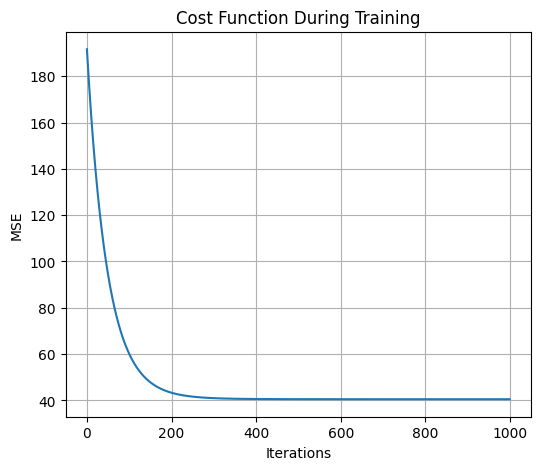

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


y_train_lr = targets.flatten()



class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.costs = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            cost = np.mean((y_pred - y) ** 2)
            self.costs.append(cost)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


lr_model = LinearRegressionGD(learning_rate=0.01, n_iterations=1000)
lr_model.fit(X_train_lr, y_train_lr)


y_train_pred = lr_model.predict(X_train_lr)
y_test_pred = lr_model.predict(X_test_lr)

train_mae = mean_absolute_error(y_train_lr, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_lr, y_train_pred))
train_mse = mean_squared_error(y_train_lr, y_train_pred)

print("=" * 60)
print("LINEAR REGRESSION WITH GRADIENT DESCENT")
print("=" * 60)
print(f"Training MAE:  {train_mae:.4f}")
print(f"Number of features: {len(lr_model.weights)}")
print(f"Bias: {lr_model.bias:.4f}")
print("=" * 60 + "\n")

# Step 7: Visualizations
plt.figure(figsize=(6, 5))

plt.plot(lr_model.costs)
plt.title('Cost Function During Training')
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.grid(True)


plt.show()

In [13]:
# Baseline 2: Simple Linear Regression Model
test_df = pd.read_csv('test.csv')
submission_linear = pd.DataFrame()
submission_linear['id'] = test_df['id']
submission_linear["pressure"] = y_test_pred
display(submission_linear)
submission_linear.to_csv('submission_baseline_linear.csv', index=False)


,id,pressure
0,1,16.924075
1,2,17.264488
2,3,17.587759
3,4,17.885769
4,5,18.116349
...,...,...
4023995,4023996,7.811977
4023996,4023997,7.812180
4023997,4023998,7.812350
4023998,4023999,7.812494


## Lasso Regression

In [14]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

y_train_lr = targets.flatten()

print(f"X_train shape: {X_train_lr.shape}")
print(f"X_test shape: {X_test_lr.shape}")
print(f"y_train shape: {y_train_lr.shape}\n")


alphas = [0.001, 0.01, 0.1, 1.0]
lasso_models = {}
lasso_results = {}

for alpha in alphas:
    lasso = SGDRegressor(penalty='l1', loss='squared_error', alpha=alpha, 
                         max_iter=500, learning_rate='optimal', eta0=0.01, 
                         random_state=42, warm_start=False)
    lasso.fit(X_train_lr, y_train_lr)
    
    y_train_pred_lasso = lasso.predict(X_train_lr)
    
    mae = mean_absolute_error(y_train_lr, y_train_pred_lasso)
    mse = mean_squared_error(y_train_lr, y_train_pred_lasso)
    rmse = np.sqrt(mse)
    
    lasso_models[alpha] = lasso
    lasso_results[alpha] = {'mae': mae, 'mse': mse, 'rmse': rmse}


best_alpha = min(lasso_results, key=lambda x: lasso_results[x]['mae'])
print(f"Best Alpha selected: {best_alpha} (lowest MAE)\n")

lasso_model = lasso_models[best_alpha]
y_train_pred_lasso = lasso_model.predict(X_train_lr)
y_test_pred_lasso = lasso_model.predict(X_test_lr)

train_mae_lasso = mean_absolute_error(y_train_lr, y_train_pred_lasso)
train_mse_lasso = mean_squared_error(y_train_lr, y_train_pred_lasso)
train_rmse_lasso = np.sqrt(train_mse_lasso)

print("-" * 60)
print("LASSO REGRESSION (L1 PENALTY - GRADIENT DESCENT)")
print("=" * 60)
print(f"Best Alpha: {best_alpha}")
print(f"Training MAE:  {train_mae_lasso:.4f}")
print(f"Number of features: {len(lasso_model.coef_)}")
print(f"Intercept: {lasso_model.intercept_[0]:.4f}")
print(f"Non-zero coefficients (sparsity): {np.sum(lasso_model.coef_ != 0)}/{len(lasso_model.coef_)}")
print("-" * 60)

print("Comparing Alpha (Sorted by MAE):")
sorted_alphas = sorted(lasso_results, key=lambda x: lasso_results[x]['mae'])
for alpha in sorted_alphas:
    marker = " <-- Best" if alpha == best_alpha else ""
    print(f"Alpha={alpha}: MAE={lasso_results[alpha]['mae']:.4f}{marker}")
print()



print("Creating detailed learning curve for best alpha: \n")
iterations = range(1, 501, 10)
best_alpha_maes = []
best_alpha_mses = []

for max_iter in iterations:
    lasso_iter = SGDRegressor(penalty='l1', loss='squared_error', alpha=best_alpha,
                              max_iter=max_iter, learning_rate='optimal', eta0=0.01,
                              random_state=42, warm_start=False)
    lasso_iter.fit(X_train_lr, y_train_lr)
    y_pred_iter = lasso_iter.predict(X_train_lr)
    
    mae_iter = mean_absolute_error(y_train_lr, y_pred_iter)
    mse_iter = mean_squared_error(y_train_lr, y_pred_iter)
    best_alpha_maes.append(mae_iter)
    best_alpha_mses.append(mse_iter)




plt.figure(figsize=(6, 5))
alphas_list = list(lasso_results.keys())
maes = [lasso_results[a]['mae'] for a in alphas_list]
mses = [lasso_results[a]['mse'] for a in alphas_list]
rmses = [lasso_results[a]['rmse'] for a in alphas_list]


print('-' * 60)
print(f"Analysis of cost function for the best alpha (α={best_alpha})")
print(f"{'='*60}")

print(f"Final MAE: {best_alpha_maes[-1]:.4f}")
print("-" * 60)

X_train shape: (6036000, 8)
X_test shape: (4024000, 8)
y_train shape: (6036000,)

Best Alpha selected: 0.01 (lowest MAE)

------------------------------------------------------------
LASSO REGRESSION (L1 PENALTY - GRADIENT DESCENT)
Best Alpha: 0.01
Training MAE:  3.9725
Number of features: 8
Intercept: 11.2184
Non-zero coefficients (sparsity): 4/8
------------------------------------------------------------
Comparing Alpha (Sorted by MAE):
Alpha=0.01: MAE=3.9725 <-- Best
Alpha=0.001: MAE=3.9737
Alpha=0.1: MAE=3.9815
Alpha=1.0: MAE=4.2660

Creating detailed learning curve for best alpha: 



/Users/sadra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


------------------------------------------------------------
Analysis of cost function for the best alpha (α=0.01)
Final MAE: 3.9725
------------------------------------------------------------


<Figure size 600x500 with 0 Axes>

In [15]:
# Saving predictions for submission
submission_lasso = pd.DataFrame()
submission_lasso['id'] = test_df['id']
submission_lasso["pressure"] = y_test_pred_lasso
display(submission_lasso)
submission_lasso.to_csv('submission_lasso_gd.csv', index=False)

,id,pressure
0,1,16.930075
1,2,17.254077
2,3,17.561763
3,4,17.845406
4,5,18.064869
...,...,...
4023995,4023996,7.810338
4023996,4023997,7.810531
4023997,4023998,7.810693
4023998,4023999,7.810830


## Ridge Regression

In [16]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


y_train_lr = targets.flatten()


# Finding the best alpha
alphas = [0.001, 0.01, 0.1, 1.0]
ridge_models = {}
ridge_results = {}

for alpha in alphas:
    print(alpha)
    ridge = SGDRegressor(penalty='l2', loss='squared_error', alpha=alpha, 
                         max_iter=500, learning_rate='optimal', eta0=0.01, 
                         random_state=42, warm_start=False)
    ridge.fit(X_train_lr, y_train_lr)
    
    y_train_pred_ridge = ridge.predict(X_train_lr)
    
    mae = mean_absolute_error(y_train_lr, y_train_pred_ridge)
    mse = mean_squared_error(y_train_lr, y_train_pred_ridge)
    rmse = np.sqrt(mse)
    
    ridge_models[alpha] = ridge
    ridge_results[alpha] = {'mae': mae, 'mse': mse, 'rmse': rmse}

best_alpha = min(ridge_results, key=lambda x: ridge_results[x]['mae'])
print(f"Best Alpha selected: {best_alpha} (lowest MAE)\n")

ridge_model = ridge_models[best_alpha]
y_train_pred_ridge = ridge_model.predict(X_train_lr)
y_test_pred_ridge = ridge_model.predict(X_test_lr)

train_mae_ridge = mean_absolute_error(y_train_lr, y_train_pred_ridge)
train_mse_ridge = mean_squared_error(y_train_lr, y_train_pred_ridge)
train_rmse_ridge = np.sqrt(train_mse_ridge)

print("-" * 60)
print("Ridge Regression (L2 penalty - Gradient Descent)")
print("-" * 60)
print(f"Best Alpha: {best_alpha}")
print(f"Training MAE:  {train_mae_ridge:.4f}")
print(f"Number of features: {len(ridge_model.coef_)}")
print(f"Intercept: {ridge_model.intercept_[0]:.4f}")
print("-" * 60)

print("Alpha Comparison (Sorted by MAE):")
sorted_alphas = sorted(ridge_results, key=lambda x: ridge_results[x]['mae'])
for alpha in sorted_alphas:
    marker = " <-- Best" if alpha == best_alpha else ""
    print(f"Alpha={alpha}: MAE={ridge_results[alpha]['mae']:.4f}{marker}")
print()

print("Creating detailed learning curve for best alpha...\n")
iterations = range(1, 501, 10)
best_alpha_maes = []


for max_iter in iterations:
    print(f"Training with max_iter={max_iter}...")
    ridge_iter = SGDRegressor(penalty='l2', loss='squared_error', alpha=best_alpha,
                              max_iter=max_iter, learning_rate='optimal', eta0=0.01,
                              random_state=42, warm_start=False)
    ridge_iter.fit(X_train_lr, y_train_lr)
    y_pred_iter = ridge_iter.predict(X_train_lr)
    
    mae_iter = mean_absolute_error(y_train_lr, y_pred_iter)
    mse_iter = mean_squared_error(y_train_lr, y_pred_iter)
    best_alpha_maes.append(mae_iter)



alphas_list = list(ridge_results.keys())
maes = [ridge_results[a]['mae'] for a in alphas_list]

print("-"*60)

print(f"Final MAE: {best_alpha_maes[-1]:.4f}")

print("-"*60)

0.001
0.01
0.1
1.0
Best Alpha selected: 0.01 (lowest MAE)

------------------------------------------------------------
Ridge Regression (L2 penalty - Gradient Descent)
------------------------------------------------------------
Best Alpha: 0.01
Training MAE:  3.9812
Number of features: 8
Intercept: 11.2184
------------------------------------------------------------
Alpha Comparison (Sorted by MAE):
Alpha=0.01: MAE=3.9812 <-- Best
Alpha=0.001: MAE=3.9865
Alpha=0.1: MAE=4.0700
Alpha=1.0: MAE=4.7565

Creating detailed learning curve for best alpha...

Training with max_iter=1...


/Users/sadra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Training with max_iter=11...
Training with max_iter=21...
Training with max_iter=31...
Training with max_iter=41...
Training with max_iter=51...
Training with max_iter=61...
Training with max_iter=71...
Training with max_iter=81...
Training with max_iter=91...
Training with max_iter=101...
Training with max_iter=111...
Training with max_iter=121...
Training with max_iter=131...
Training with max_iter=141...
Training with max_iter=151...
Training with max_iter=161...
Training with max_iter=171...
Training with max_iter=181...
Training with max_iter=191...
Training with max_iter=201...
Training with max_iter=211...
Training with max_iter=221...
Training with max_iter=231...
Training with max_iter=241...
Training with max_iter=251...
Training with max_iter=261...
Training with max_iter=271...
Training with max_iter=281...
Training with max_iter=291...
Training with max_iter=301...
Training with max_iter=311...
Training with max_iter=321...
Training with max_iter=331...
Training with max_i

In [17]:
# Saving predictions for submission
submission_ridge = pd.DataFrame()
submission_ridge['id'] = test_df['id']
submission_ridge["pressure"] = y_test_pred_ridge
display(submission_ridge)
submission_ridge.to_csv('submission_ridge_gd.csv', index=False)

,id,pressure
0,1,16.860211
1,2,17.198521
2,3,17.519794
3,4,17.815962
4,5,18.045117
...,...,...
4023995,4023996,7.858075
4023996,4023997,7.858276
4023997,4023998,7.858445
4023998,4023999,7.858588


## Random Forest Regressor

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


y_train_rf = targets.flatten()


rf = RandomForestRegressor(n_estimators=100, max_depth=15, 
                               min_samples_split=5, min_samples_leaf=2,
                               random_state=42, n_jobs=-1)
rf.fit(X_train_lr, y_train_rf)
    
y_train_pred_rf = rf.predict(X_train_lr)
    
mae = mean_absolute_error(y_train_rf, y_train_pred_rf)
mse = mean_squared_error(y_train_rf, y_train_pred_rf)
rmse = np.sqrt(mse)


rf_model = rf
y_train_pred_rf = rf_model.predict(X_train_lr)
y_test_pred_rf = rf_model.predict(X_test_lr)

train_mae_rf = mean_absolute_error(y_train_rf, y_train_pred_rf)
train_mse_rf = mean_squared_error(y_train_rf, y_train_pred_rf)
train_rmse_rf = np.sqrt(train_mse_rf)

print("=" * 60)
print("RANDOM FOREST REGRESSOR")
print("=" * 60)
print(f"Training MAE:  {train_mae_rf:.4f}")
print(f"Number of features: {len(selected_features)}")
print('-' * 60)

RANDOM FOREST REGRESSOR
Training MAE:  3.2472
Number of features: 8
------------------------------------------------------------


In [19]:
# Saving predictions for submission
submission_rf = pd.DataFrame()
submission_rf['id'] = test_df['id']
submission_rf["pressure"] = y_test_pred_rf
display(submission_rf)
submission_rf.to_csv('submission_random_forest.csv', index=False)

,id,pressure
0,1,15.519642
1,2,14.334154
2,3,16.749752
3,4,19.018790
4,5,18.175461
...,...,...
4023995,4023996,6.064152
4023996,4023997,6.120807
4023997,4023998,6.090694
4023998,4023999,6.071102
